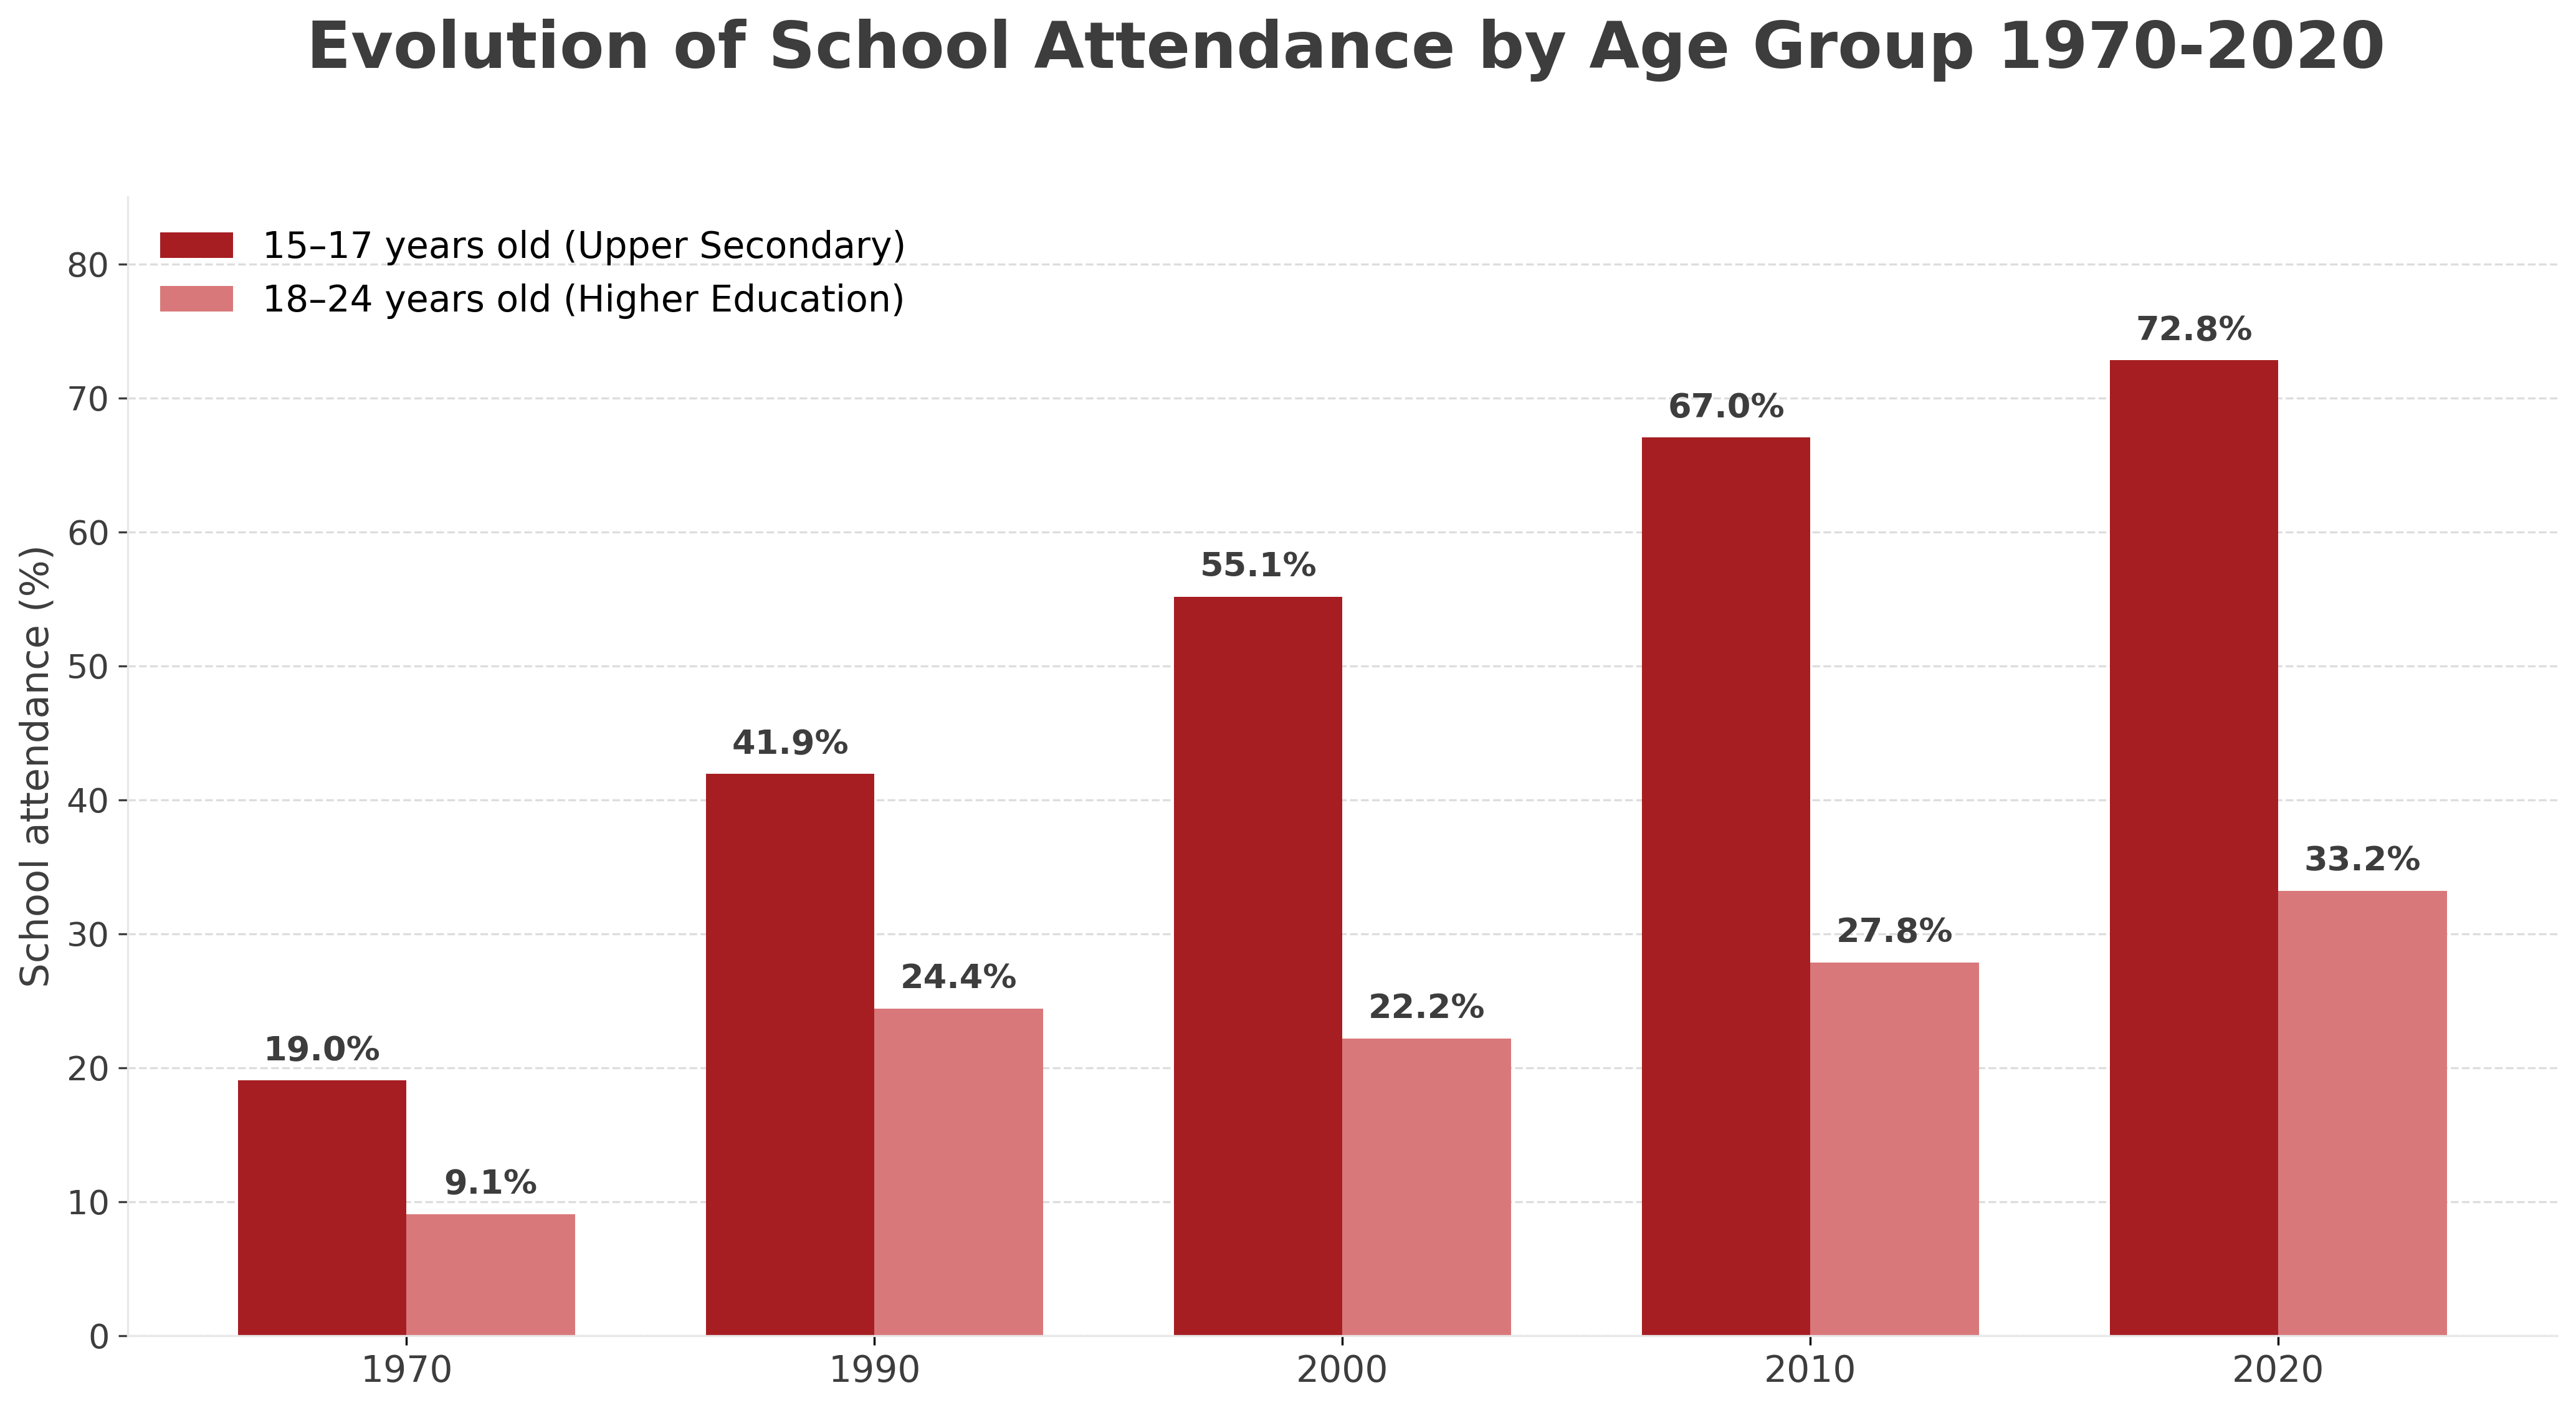

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# =============================================================================
# ESTILO INSTITUCIONAL
# =============================================================================
plt.rcParams["font.family"] = "DejaVu Sans"

COLOR_PRINCIPAL = "#A61E22"
COLOR_DESTACADO = "#D97A1D"
COLOR_SECUNDARIO = "#D9787A"

GRIS_OSCURO = "#3D3D3D"
GRIS_MEDIO = "#7A7A7A"
GRIS_CLARO = "#E8E8E8"

# =============================================================================
# DATOS
# =============================================================================
anios = ["1970", "1990", "2000", "2010", "2020"]

asiste_15_17 = [19.04, 41.92, 55.15, 67.04, 72.80]
asiste_18_24 = [9.05, 24.41, 22.19, 27.84, 33.21]

x = np.arange(len(anios))
width = 0.36

# =============================================================================
# FIGURA
# =============================================================================
fig, ax = plt.subplots(figsize=(14, 8))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")

# =============================================================================
# BARRAS
# =============================================================================
bars1 = ax.bar(
    x - width / 2,
    asiste_15_17,
    width,
    label="15–17 years old (Upper Secondary)",
    color=COLOR_PRINCIPAL,
    linewidth=0
)

bars2 = ax.bar(
    x + width / 2,
    asiste_18_24,
    width,
    label="18–24 years old (Higher Education)",
    color=COLOR_SECUNDARIO,
    linewidth=0
)

# =============================================================================
# ETIQUETAS DE VALOR
# =============================================================================
for bars in [bars1, bars2]:
    for bar in bars:

        h = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 1,
            f"{h:.1f}%",
            ha="center",
            va="bottom",
            fontsize=13,
            fontweight="bold",
            color=GRIS_OSCURO
        )

# =============================================================================
# TÍTULO Y SUBTÍTULO
# =============================================================================
fig.text(
    0.125,
    0.96,
    "Evolution of School Attendance by Age Group 1970-2020",
    fontsize=25,
    fontweight="bold",
    color=GRIS_OSCURO
)



# =============================================================================
# EJES
# =============================================================================
ax.set_ylabel(
    "School attendance (%)",
    fontsize=15,
    color=GRIS_OSCURO
)

ax.set_xticks(x)

ax.set_xticklabels(
    anios,
    fontsize=14,
    color=GRIS_OSCURO
)

ax.tick_params(
    axis="y",
    labelsize=13,
    colors=GRIS_OSCURO
)

ax.set_ylim(0, 85)

# =============================================================================
# GRID
# =============================================================================
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.25,
    color=GRIS_MEDIO
)

ax.set_axisbelow(True)

# =============================================================================
# SPINES
# =============================================================================
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color(GRIS_CLARO)
ax.spines["bottom"].set_color(GRIS_CLARO)

# =============================================================================
# LEYENDA
# =============================================================================
ax.legend(
    frameon=False,
    fontsize=14,
    loc="upper left"
)

# =============================================================================
# AJUSTES FINALES
# =============================================================================
plt.tight_layout(rect=[0, 0.05, 1, 0.90])

# =============================================================================
# EXPORTACIÓN
# =============================================================================
plt.savefig(
    "grafica (a).svg",
    format="svg",
    bbox_inches="tight",
    dpi=300
)

plt.show()

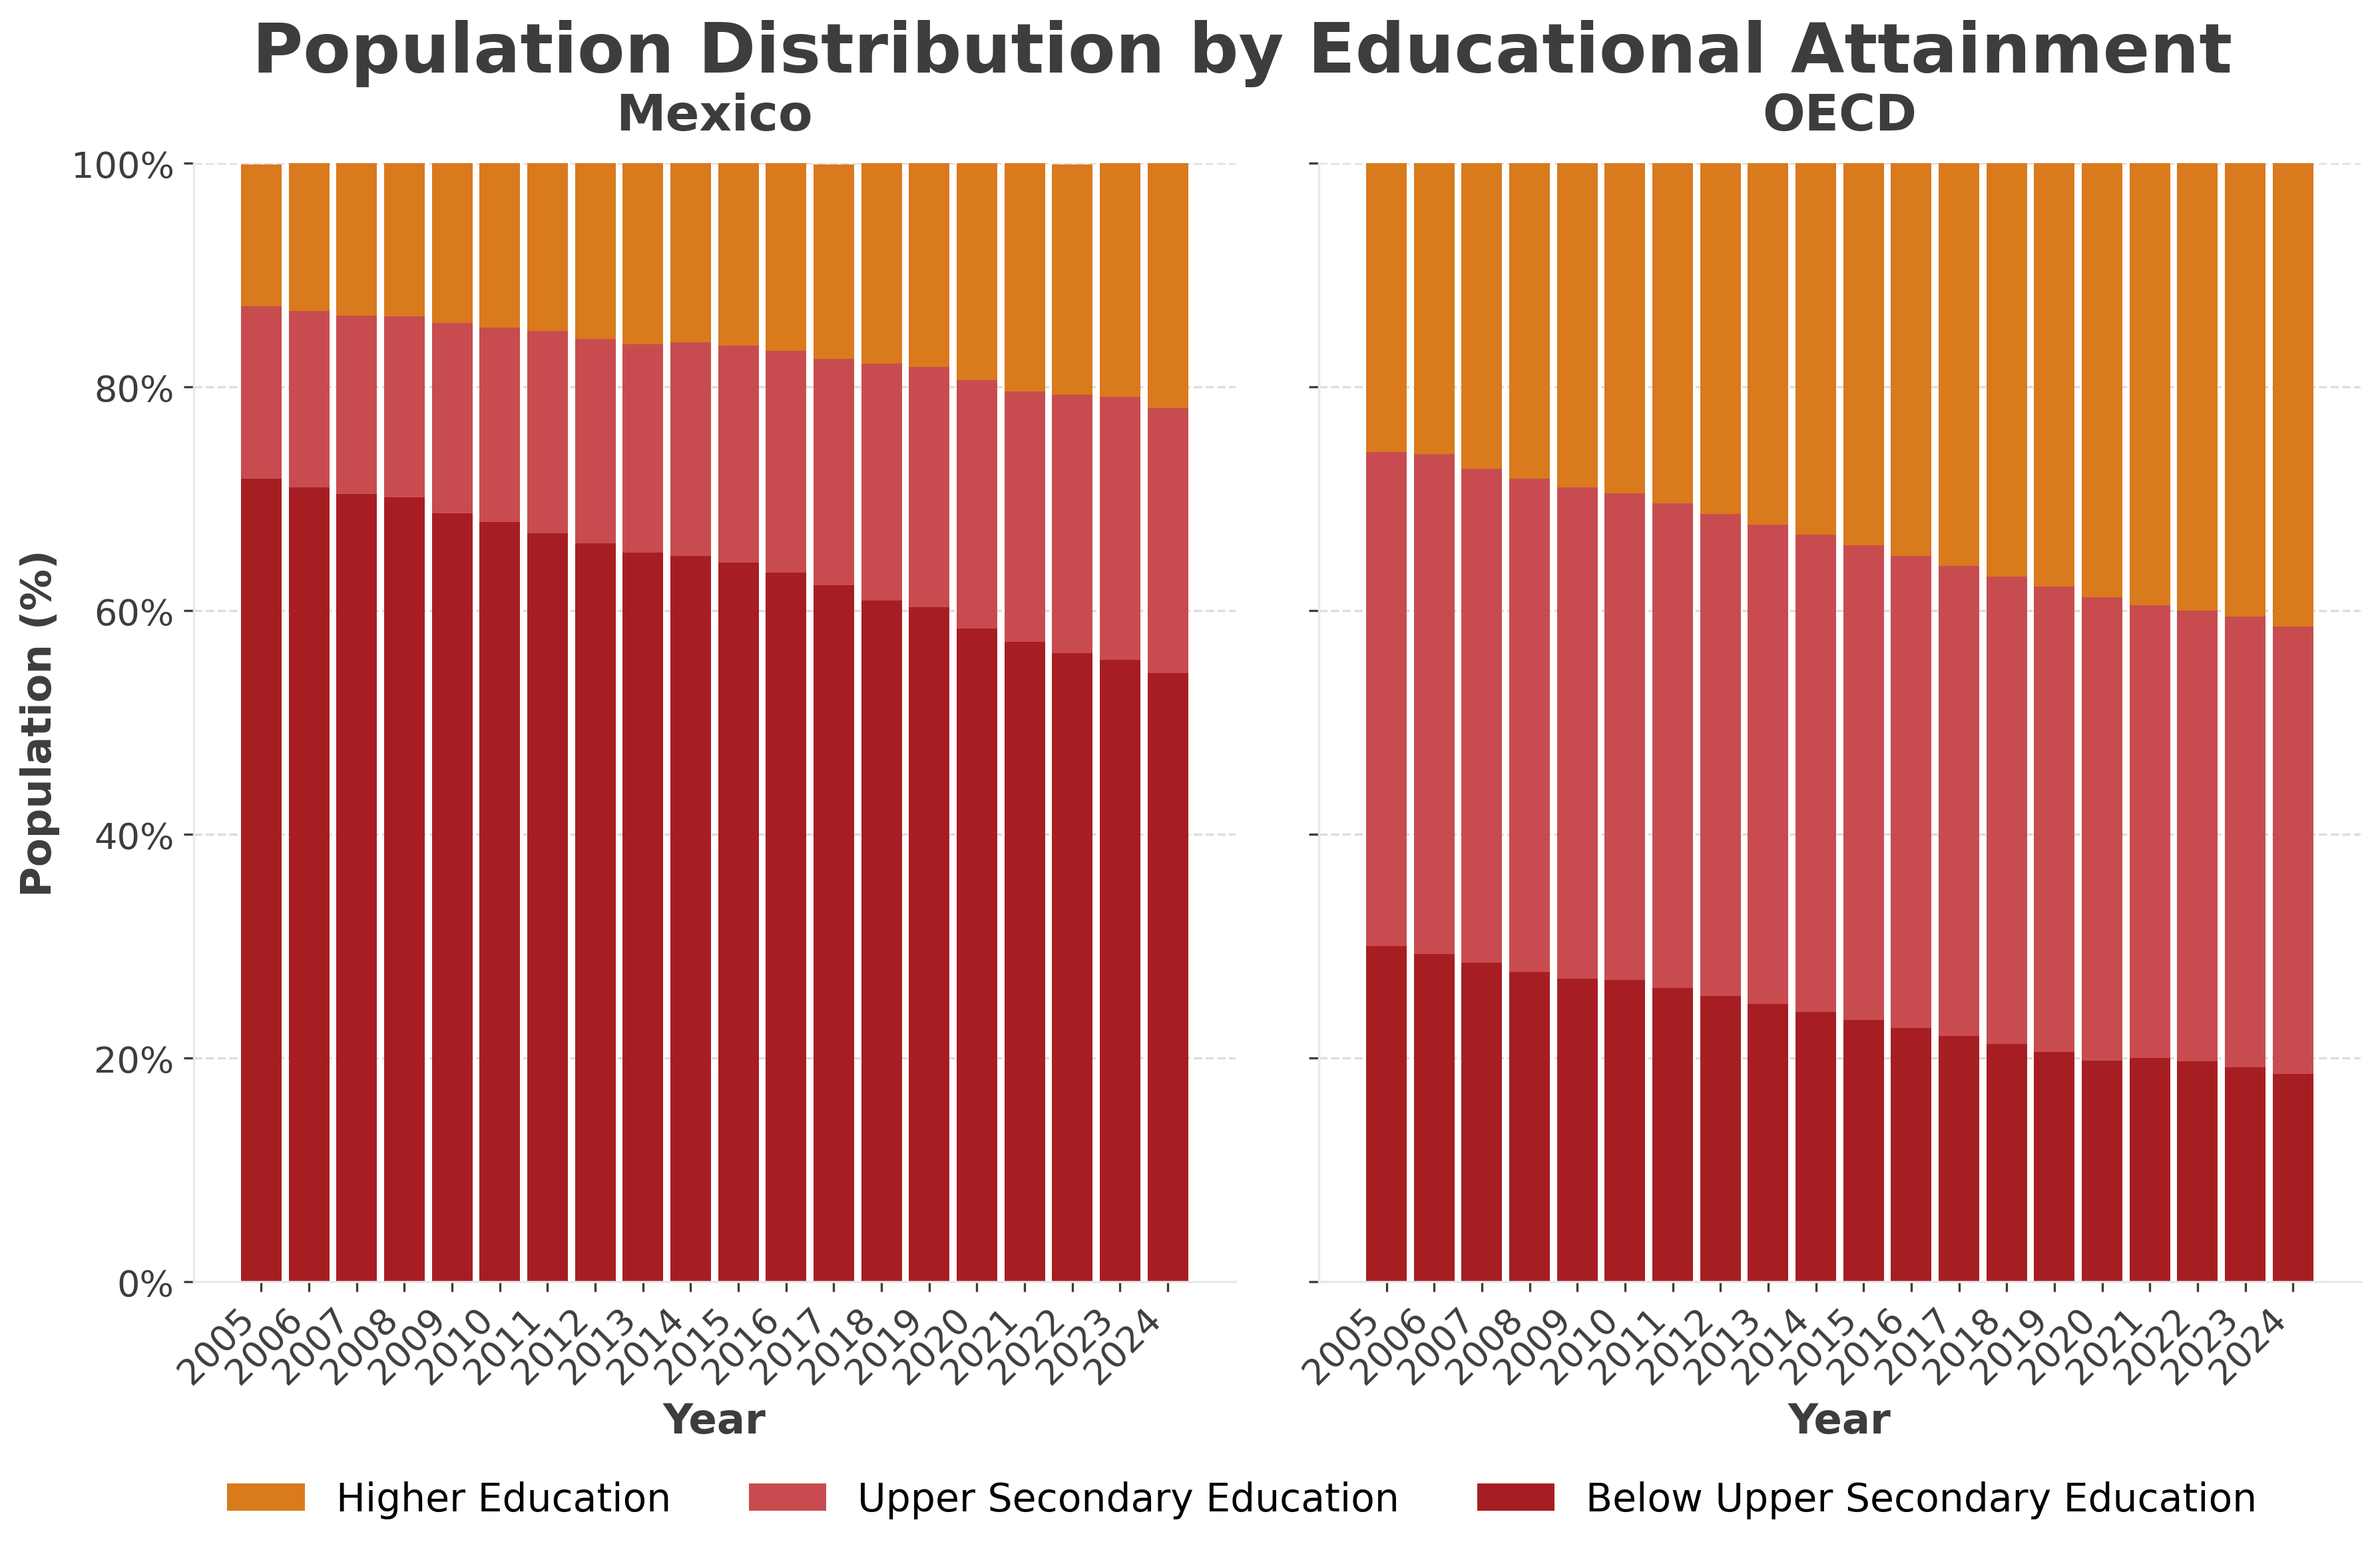

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# ==========================================================
# INSTITUTIONAL STYLE
# ==========================================================
plt.rcParams["font.family"] = "DejaVu Sans"

COLOR_PRIMARY = "#A61E22"
COLOR_HIGHLIGHT = "#D97A1D"
COLOR_SECONDARY_1 = "#C84C4F"
COLOR_SECONDARY_2 = "#D9787A"
COLOR_SECONDARY_3 = "#E5A6A7"

DARK_GREY = "#3D3D3D"
MEDIUM_GREY = "#7A7A7A"
LIGHT_GREY = "#E8E8E8"

# ==========================================================
# DATA
# ==========================================================
data = {
    'Year': list(range(2005, 2025)),

    'Mex_Below': [71.8, 71.0, 70.4, 70.1, 68.7, 67.9, 66.9, 66.0, 65.2, 64.9, 64.3, 63.4, 62.3, 60.9, 60.3, 58.4, 57.2, 56.2, 55.6, 54.4],
    'Mex_Upper': [15.4, 15.8, 16.0, 16.2, 17.0, 17.4, 18.1, 18.3, 18.6, 19.1, 19.4, 19.8, 20.2, 21.2, 21.5, 22.2, 22.4, 23.1, 23.5, 23.7],
    'Mex_Higher': [12.7, 13.3, 13.6, 13.7, 14.3, 14.7, 15.0, 15.7, 16.2, 16.0, 16.3, 16.8, 17.4, 18.0, 18.3, 19.4, 20.5, 20.6, 21.0, 21.9],

    'OECD_Below': [30.0, 29.3, 28.5, 27.7, 27.1, 27.0, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 19.8, 20.0, 19.7, 19.2, 18.6],
    'OECD_Upper': [44.2, 44.7, 44.2, 44.1, 43.9, 43.5, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 41.4, 40.5, 40.3, 40.3, 40.0],
    'OECD_Higher': [26.3, 26.5, 27.6, 28.6, 29.3, 29.9, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, 39.2, 39.9, 40.4, 40.9, 41.8]
}

df = pd.DataFrame(data)

# ==========================================================
# INTERPOLATE MISSING OECD VALUES
# ==========================================================
for col in ['OECD_Below', 'OECD_Upper', 'OECD_Higher']:
    df[col] = df[col].interpolate()

df['Year'] = df['Year'].astype(str)

# ==========================================================
# EDUCATION COLORS
# ==========================================================
color_below = COLOR_PRIMARY
color_upper = COLOR_SECONDARY_1
color_higher = COLOR_HIGHLIGHT

# ==========================================================
# FIGURE
# ==========================================================
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 8),
    sharey=True
)

fig.patch.set_facecolor("white")

# ==========================================================
# STYLE FUNCTION
# ==========================================================
def apply_style(ax):

    ax.set_facecolor("white")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.spines["left"].set_color(LIGHT_GREY)
    ax.spines["bottom"].set_color(LIGHT_GREY)

    ax.grid(
        axis="y",
        linestyle="--",
        linewidth=0.8,
        alpha=0.25,
        color=MEDIUM_GREY
    )

    ax.set_axisbelow(True)

    ax.tick_params(
        axis="x",
        labelsize=13,
        colors=DARK_GREY,
        rotation=45
    )

    ax.tick_params(
        axis="y",
        labelsize=13,
        colors=DARK_GREY
    )

    for tick in ax.get_xticklabels():
        tick.set_ha("right")

# ==========================================================
# MEXICO
# ==========================================================
ax1.bar(
    df["Year"],
    df["Mex_Below"],
    color=color_below,
    width=0.85,
    linewidth=0
)

ax1.bar(
    df["Year"],
    df["Mex_Upper"],
    bottom=df["Mex_Below"],
    color=color_upper,
    width=0.85,
    linewidth=0
)

ax1.bar(
    df["Year"],
    df["Mex_Higher"],
    bottom=df["Mex_Below"] + df["Mex_Upper"],
    color=color_higher,
    width=0.85,
    linewidth=0
)

ax1.set_title(
    "Mexico",
    fontsize=18,
    fontweight="bold",
    color=DARK_GREY,
    pad=12
)

ax1.set_ylabel(
    "Population (%)",
    fontsize=15,
    color=DARK_GREY,
    fontweight="bold"
)

# ==========================================================
# OECD
# ==========================================================
ax2.bar(
    df["Year"],
    df["OECD_Below"],
    color=color_below,
    width=0.85,
    linewidth=0
)

ax2.bar(
    df["Year"],
    df["OECD_Upper"],
    bottom=df["OECD_Below"],
    color=color_upper,
    width=0.85,
    linewidth=0
)

ax2.bar(
    df["Year"],
    df["OECD_Higher"],
    bottom=df["OECD_Below"] + df["OECD_Upper"],
    color=color_higher,
    width=0.85,
    linewidth=0
)

ax2.set_title(
    "OECD",
    fontsize=18,
    fontweight="bold",
    color=DARK_GREY,
    pad=12
)

# ==========================================================
# AXIS FORMAT
# ==========================================================
for ax in [ax1, ax2]:

    apply_style(ax)

    ax.set_ylim(0, 100)

    ax.set_yticks([0, 20, 40, 60, 80, 100])

    ax.set_yticklabels(
        ["0%", "20%", "40%", "60%", "80%", "100%"]
    )

    ax.set_xlabel(
        "Year",
        fontsize=15,
        color=DARK_GREY,
        fontweight="bold"
    )

# ==========================================================
# MAIN TITLE
# ==========================================================
fig.suptitle(
    "Population Distribution by Educational Attainment",
    fontsize=25,
    fontweight="bold",
    color=DARK_GREY,
    y=0.97
)

# ==========================================================
# LEGEND
# ==========================================================
legend_elements = [
    Patch(
        facecolor=color_higher,
        label="Higher Education"
    ),
    Patch(
        facecolor=color_upper,
        label="Upper Secondary Education"
    ),
    Patch(
        facecolor=color_below,
        label="Below Upper Secondary Education"
    )
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=3,
    frameon=False,
    fontsize=14
)

# ==========================================================
# FINAL ADJUSTMENTS
# ==========================================================
plt.subplots_adjust(
    top=0.88,
    bottom=0.18,
    wspace=0.08
)

# ==========================================================
# EXPORT
# ==========================================================
plt.savefig(
    "grafica (b).svg",
    format="svg",
    bbox_inches="tight",
    dpi=300
)

plt.show()

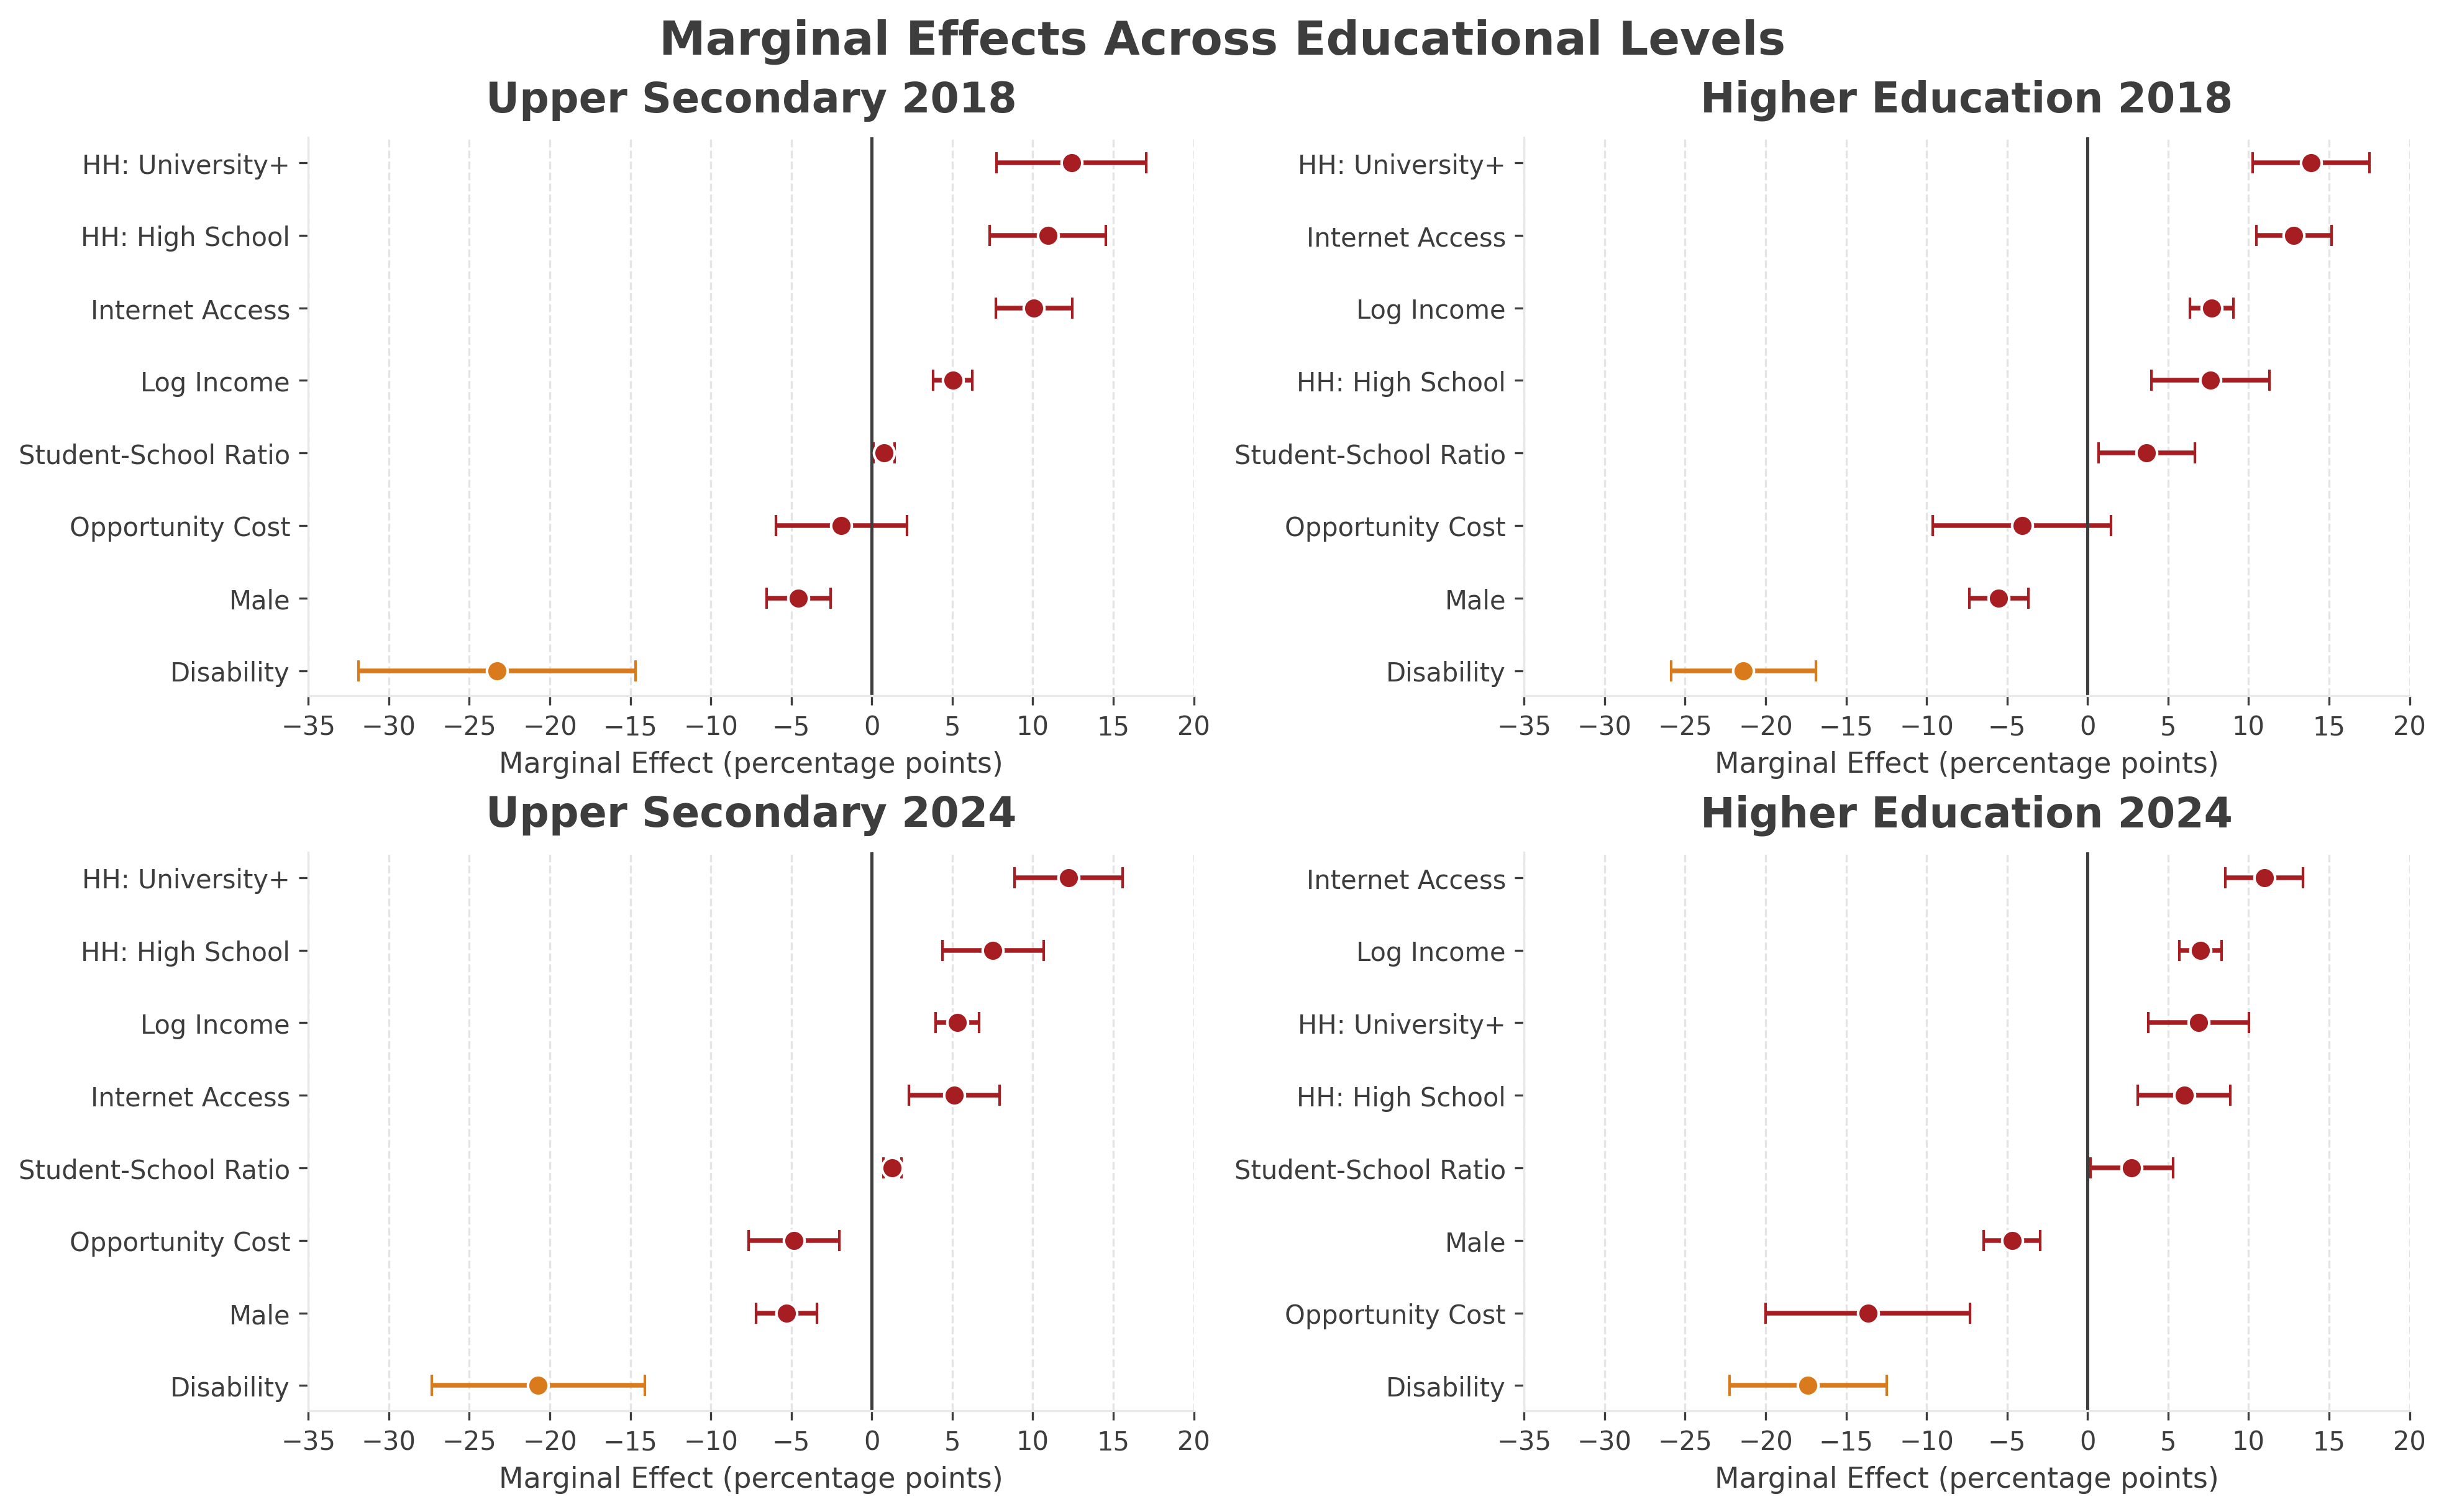

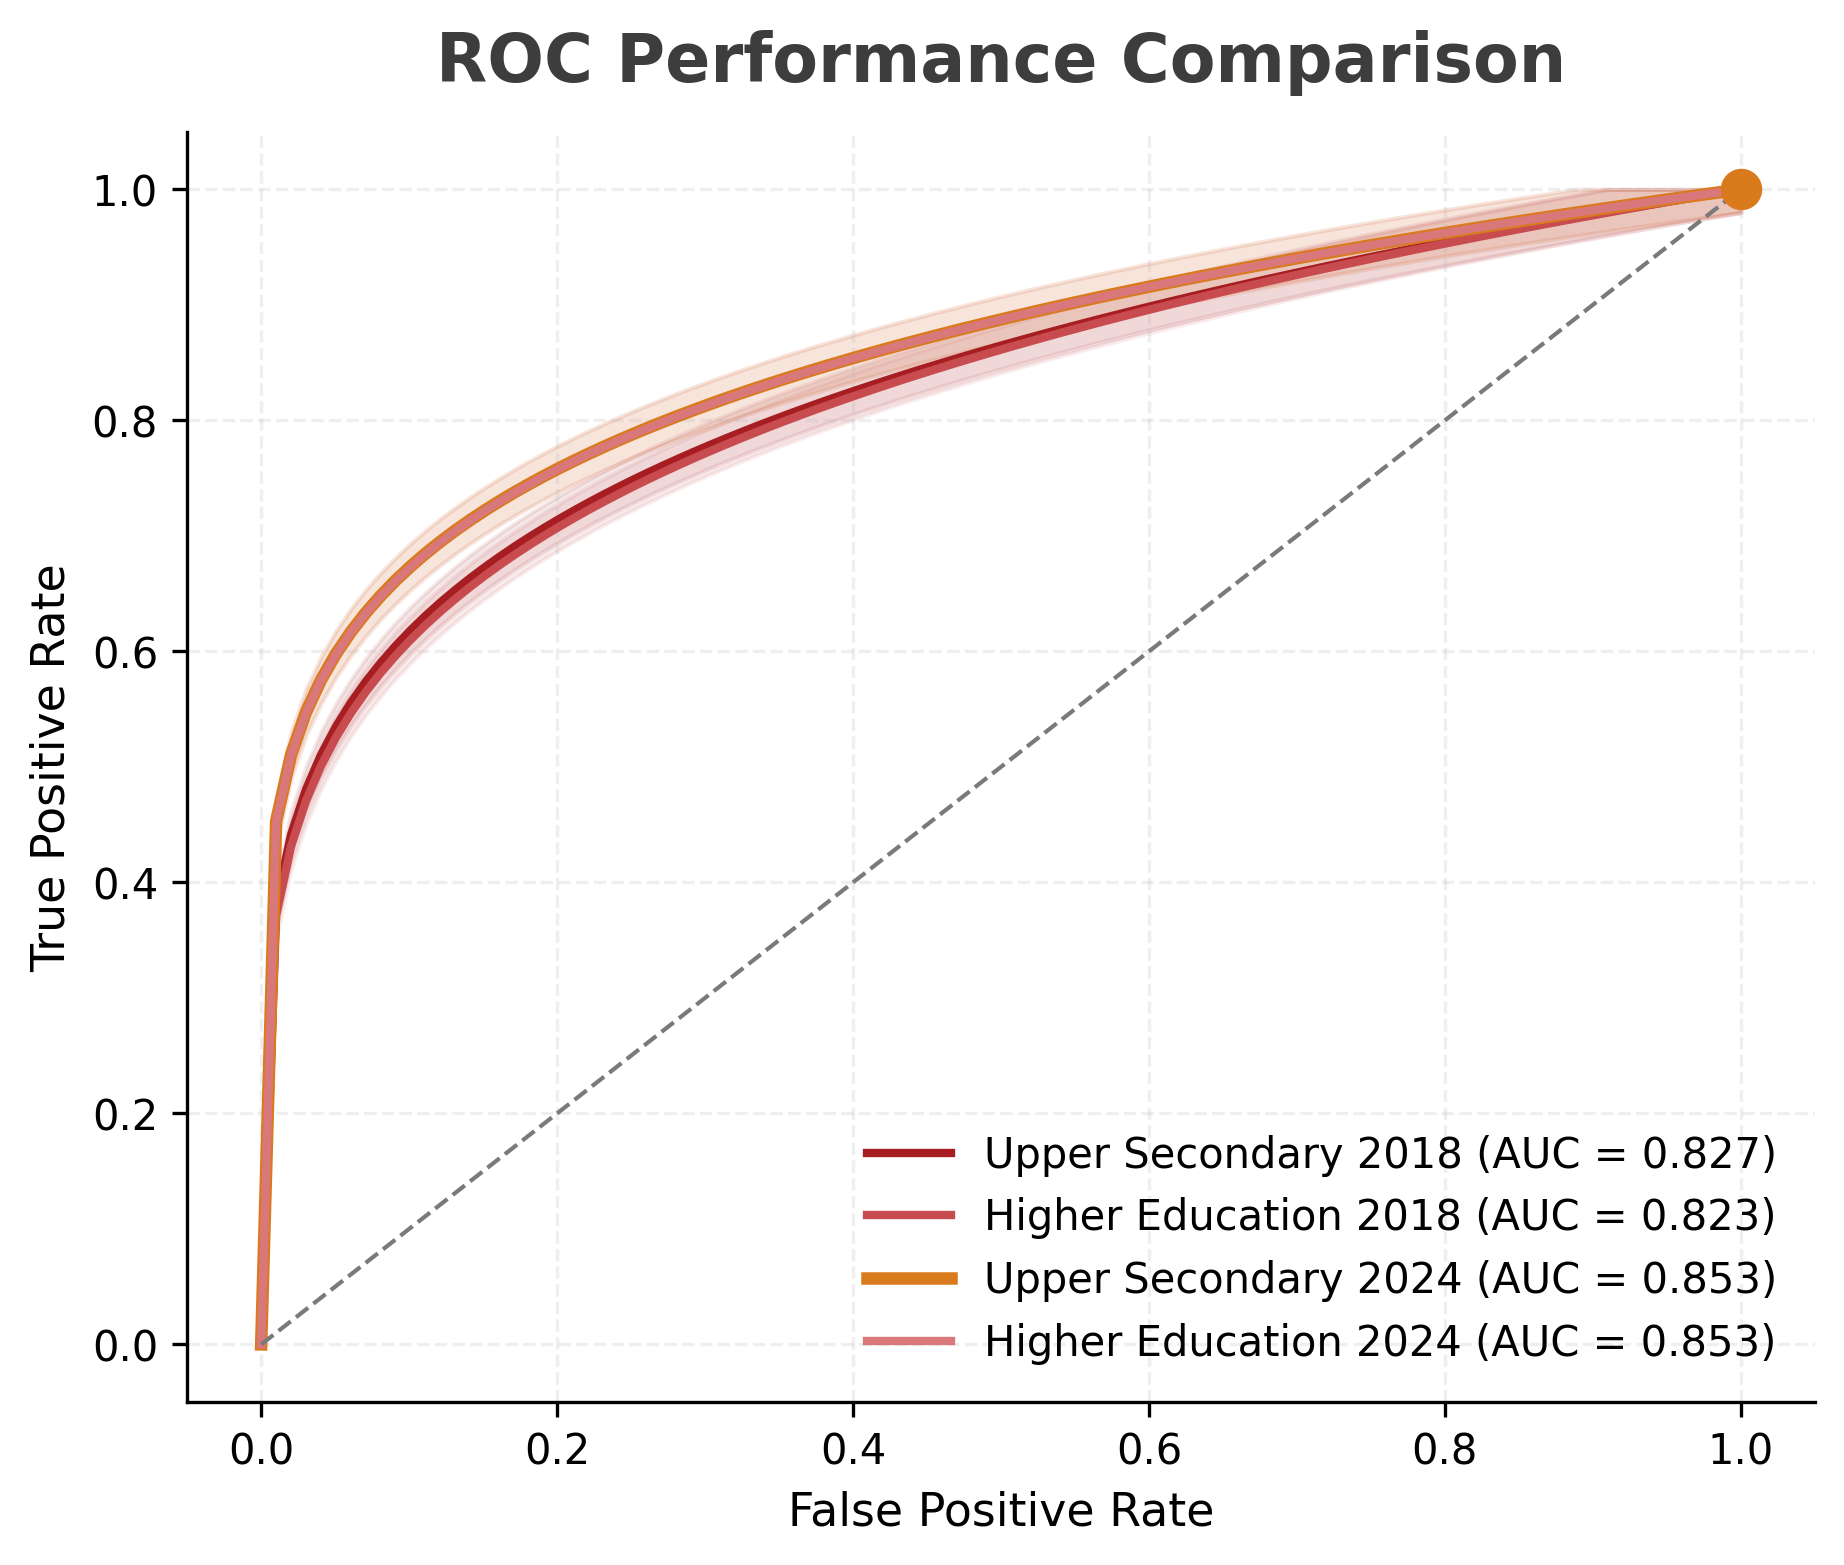

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# =====================================================
# IDENTIDAD VISUAL INSTITUCIONAL
# =====================================================

PRIMARY = "#A61E22"
ACCENT = "#D97A1D"

RED_2 = "#C84C4F"
RED_3 = "#D9787A"
RED_4 = "#E5A6A7"

DARK = "#3D3D3D"
MID = "#7A7A7A"
LIGHT = "#E8E8E8"
WHITE = "#FFFFFF"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 16,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "figure.dpi": 300
})

# =====================================================
# DATA
# =====================================================

variables = [
    'Disability',
    'Log Income',
    'Non-study Hours',
    'HH: Primary',
    'HH: Secondary',
    'HH: High School',
    'HH: University+',
    'Internet Access',
    'Male',
    'Age',
    'Indigenous',
    'Urban',
    'Household Size',
    'Region: Central-North',
    'Region: North',
    'Region: Northwest',
    'Region: South',
    'Student-School Ratio',
    'Opportunity Cost'
]

data = {
    'Variable': variables * 4,
    'Model': (
        ['Upper Secondary 2018'] * 19 +
        ['Higher Education 2018'] * 19 +
        ['Upper Secondary 2024'] * 19 +
        ['Higher Education 2024'] * 19
    ),
    'Effect': [

        -0.2328, 0.0503, -0.0045, 0.0180, 0.0495,
        0.1093, 0.1240, 0.1007, -0.0455, -0.0367,
        0.0013, 0.0314, -0.0144, -0.0465, -0.0238,
        0.0167, 0.0484, 0.0077, -0.0189,

        -0.2138, 0.0772, -0.0049, -0.0601, -0.0006,
        0.0762, 0.1389, 0.1282, -0.0552, -0.0510,
        -0.0024, 0.0432, -0.0152, -0.0423, -0.0216,
        0.0217, 0.0248, 0.0367, -0.0408,

        -0.2072, 0.0532, -0.0061, -0.0516, 0.0118,
        0.0753, 0.1222, 0.0513, -0.0530, -0.0275,
        0.0065, 0.0339, -0.0100, -0.0430, -0.0463,
        0.0011, 0.0007, 0.0128, -0.0484,

        -0.1736, 0.0702, -0.0078, -0.0632, -0.0122,
        0.0599, 0.0689, 0.1097, -0.0469, -0.0324,
        -0.0005, 0.0466, -0.0172, -0.0240, -0.0115,
        0.0008, -0.0360, 0.0274, -0.1365
    ]
}

df = pd.DataFrame(data)

# =====================================================
# T-STATS
# =====================================================

t_stats = {
    'Upper Secondary 2018': [-5.30, 8.09, -17.76, 1.17, 3.45, 5.96, 5.24, 8.34, -4.46, -6.84, 0.11, 2.48, -4.35, -2.55, -1.70, 1.16, 2.91, 2.29, -0.91],
    'Higher Education 2018': [-9.31, 11.20, -25.23, -3.73, -0.05, 4.08, 7.51, 10.72, -5.93, -21.97, -0.19, 3.39, -5.01, -2.54, -1.41, 1.55, 1.60, 2.40, -1.44],
    'Upper Secondary 2024': [-6.13, 7.74, -20.52, -2.80, 0.72, 4.68, 7.12, 3.58, -5.52, -5.17, 0.49, 2.78, -2.78, -2.54, -3.27, 0.09, 0.05, 4.44, -3.36],
    'Higher Education 2024': [-6.95, 10.48, -46.31, -3.98, -0.96, 4.06, 4.33, 8.86, -5.26, -13.97, -0.05, 4.00, -5.14, -1.57, -0.70, 0.07, -2.76, 2.10, -4.22]
}

# =====================================================
# FUNCTION
# =====================================================

def compute_ci(effect, t):
    se = abs(effect / t)
    return 1.96 * se

# =====================================================
# FIGURE 1 — FOREST PLOT
# =====================================================

selected_variables = [
    'HH: University+',
    'HH: High School',
    'Internet Access',
    'Male',
    'Disability',
    'Log Income',
    'Opportunity Cost',
    'Student-School Ratio'
]

x_min = -35
x_max = 20
x_ticks = np.arange(x_min, x_max + 1, 5)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8),
    constrained_layout=True,
    facecolor=WHITE
)

axes = axes.flatten()

models = [
    'Upper Secondary 2018',
    'Higher Education 2018',
    'Upper Secondary 2024',
    'Higher Education 2024'
]

for idx, ax in enumerate(axes):

    mod = models[idx]

    df_mod = df[
        (df["Model"] == mod) &
        (df["Variable"].isin(selected_variables))
    ].copy()

    df_mod["Effect"] = df_mod["Effect"] * 100
    df_mod = df_mod.sort_values("Effect")

    labels = [
        textwrap.fill(v, width=22)
        for v in df_mod["Variable"]
    ]

    y_pos = np.arange(len(labels))

    tvals = [
        t_stats[mod][variables.index(v)]
        for v in df_mod["Variable"]
    ]

    ci_vals = [
        compute_ci(eff, t)
        for eff, t in zip(df_mod["Effect"], tvals)
    ]

    highlight_idx = np.argmax(np.abs(df_mod["Effect"]))

    colors = [PRIMARY] * len(df_mod)
    colors[highlight_idx] = ACCENT

    for i in range(len(df_mod)):

        ax.errorbar(
            df_mod["Effect"].iloc[i],
            y_pos[i],
            xerr=ci_vals[i],
            fmt='o',
            color=colors[i],
            markerfacecolor=colors[i],
            markeredgecolor='white',
            markeredgewidth=1,
            markersize=8,
            capsize=4,
            elinewidth=1.8
        )

    ax.axvline(
        0,
        color=DARK,
        linewidth=1.2
    )

    ax.set_xlim(x_min, x_max)
    ax.set_xticks(x_ticks)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels)

    ax.set_title(
        mod,
        fontweight="bold",
        color=DARK,
        pad=10
    )

    ax.grid(
        axis='x',
        linestyle='--',
        alpha=0.20,
        color=MID
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax.spines['left'].set_color(LIGHT)
    ax.spines['bottom'].set_color(LIGHT)

    ax.tick_params(colors=DARK)

    ax.set_xlabel(
        "Marginal Effect (percentage points)",
        color=DARK
    )

fig.suptitle(
    "Marginal Effects Across Educational Levels",
    fontsize=18,
    fontweight="bold",
    color=DARK
)

plt.savefig(
    "grafica y.svg",
    format="svg",
    bbox_inches="tight",
    dpi=300
)

plt.show()

# =====================================================
# FIGURE 2 — ROC CURVES
# =====================================================

def get_roc_coords(auc):

    k = auc / (1 - auc)

    fpr = np.linspace(0, 1, 100)

    tpr = fpr ** (1 / k)

    return fpr, tpr

aucs = {
    'Upper Secondary 2018': 0.8267,
    'Higher Education 2018': 0.8227,
    'Upper Secondary 2024': 0.8530,
    'Higher Education 2024': 0.8528
}

fig, ax = plt.subplots(
    figsize=(7, 5.5),
    facecolor=WHITE
)

colors = {
    'Upper Secondary 2018': PRIMARY,
    'Higher Education 2018': RED_2,
    'Upper Secondary 2024': ACCENT,
    'Higher Education 2024': RED_3
}

best_model = max(aucs, key=aucs.get)

for name, val in aucs.items():

    fpr, tpr = get_roc_coords(val)

    ci_margin = 0.02

    lower = np.maximum(0, tpr - ci_margin)
    upper = np.minimum(1, tpr + ci_margin)

    lw = 3 if name == best_model else 2

    ax.plot(
        fpr,
        tpr,
        linewidth=lw,
        color=colors[name],
        label=f"{name} (AUC = {val:.3f})"
    )

    ax.fill_between(
        fpr,
        lower,
        upper,
        color=colors[name],
        alpha=0.10
    )

    if name == best_model:

        ax.scatter(
            fpr[-1],
            tpr[-1],
            s=80,
            color=ACCENT,
            zorder=10
        )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    linewidth=1,
    color=MID
)

ax.set_title(
    "ROC Performance Comparison",
    fontweight='bold',
    color=DARK,
    pad=12
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.grid(
    linestyle='--',
    alpha=0.20
)

ax.legend(
    frameon=False,
    loc='lower right'
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig(
    "grafica (4).svg",
    format="svg",
    bbox_inches="tight",
    dpi=300
)

plt.show()



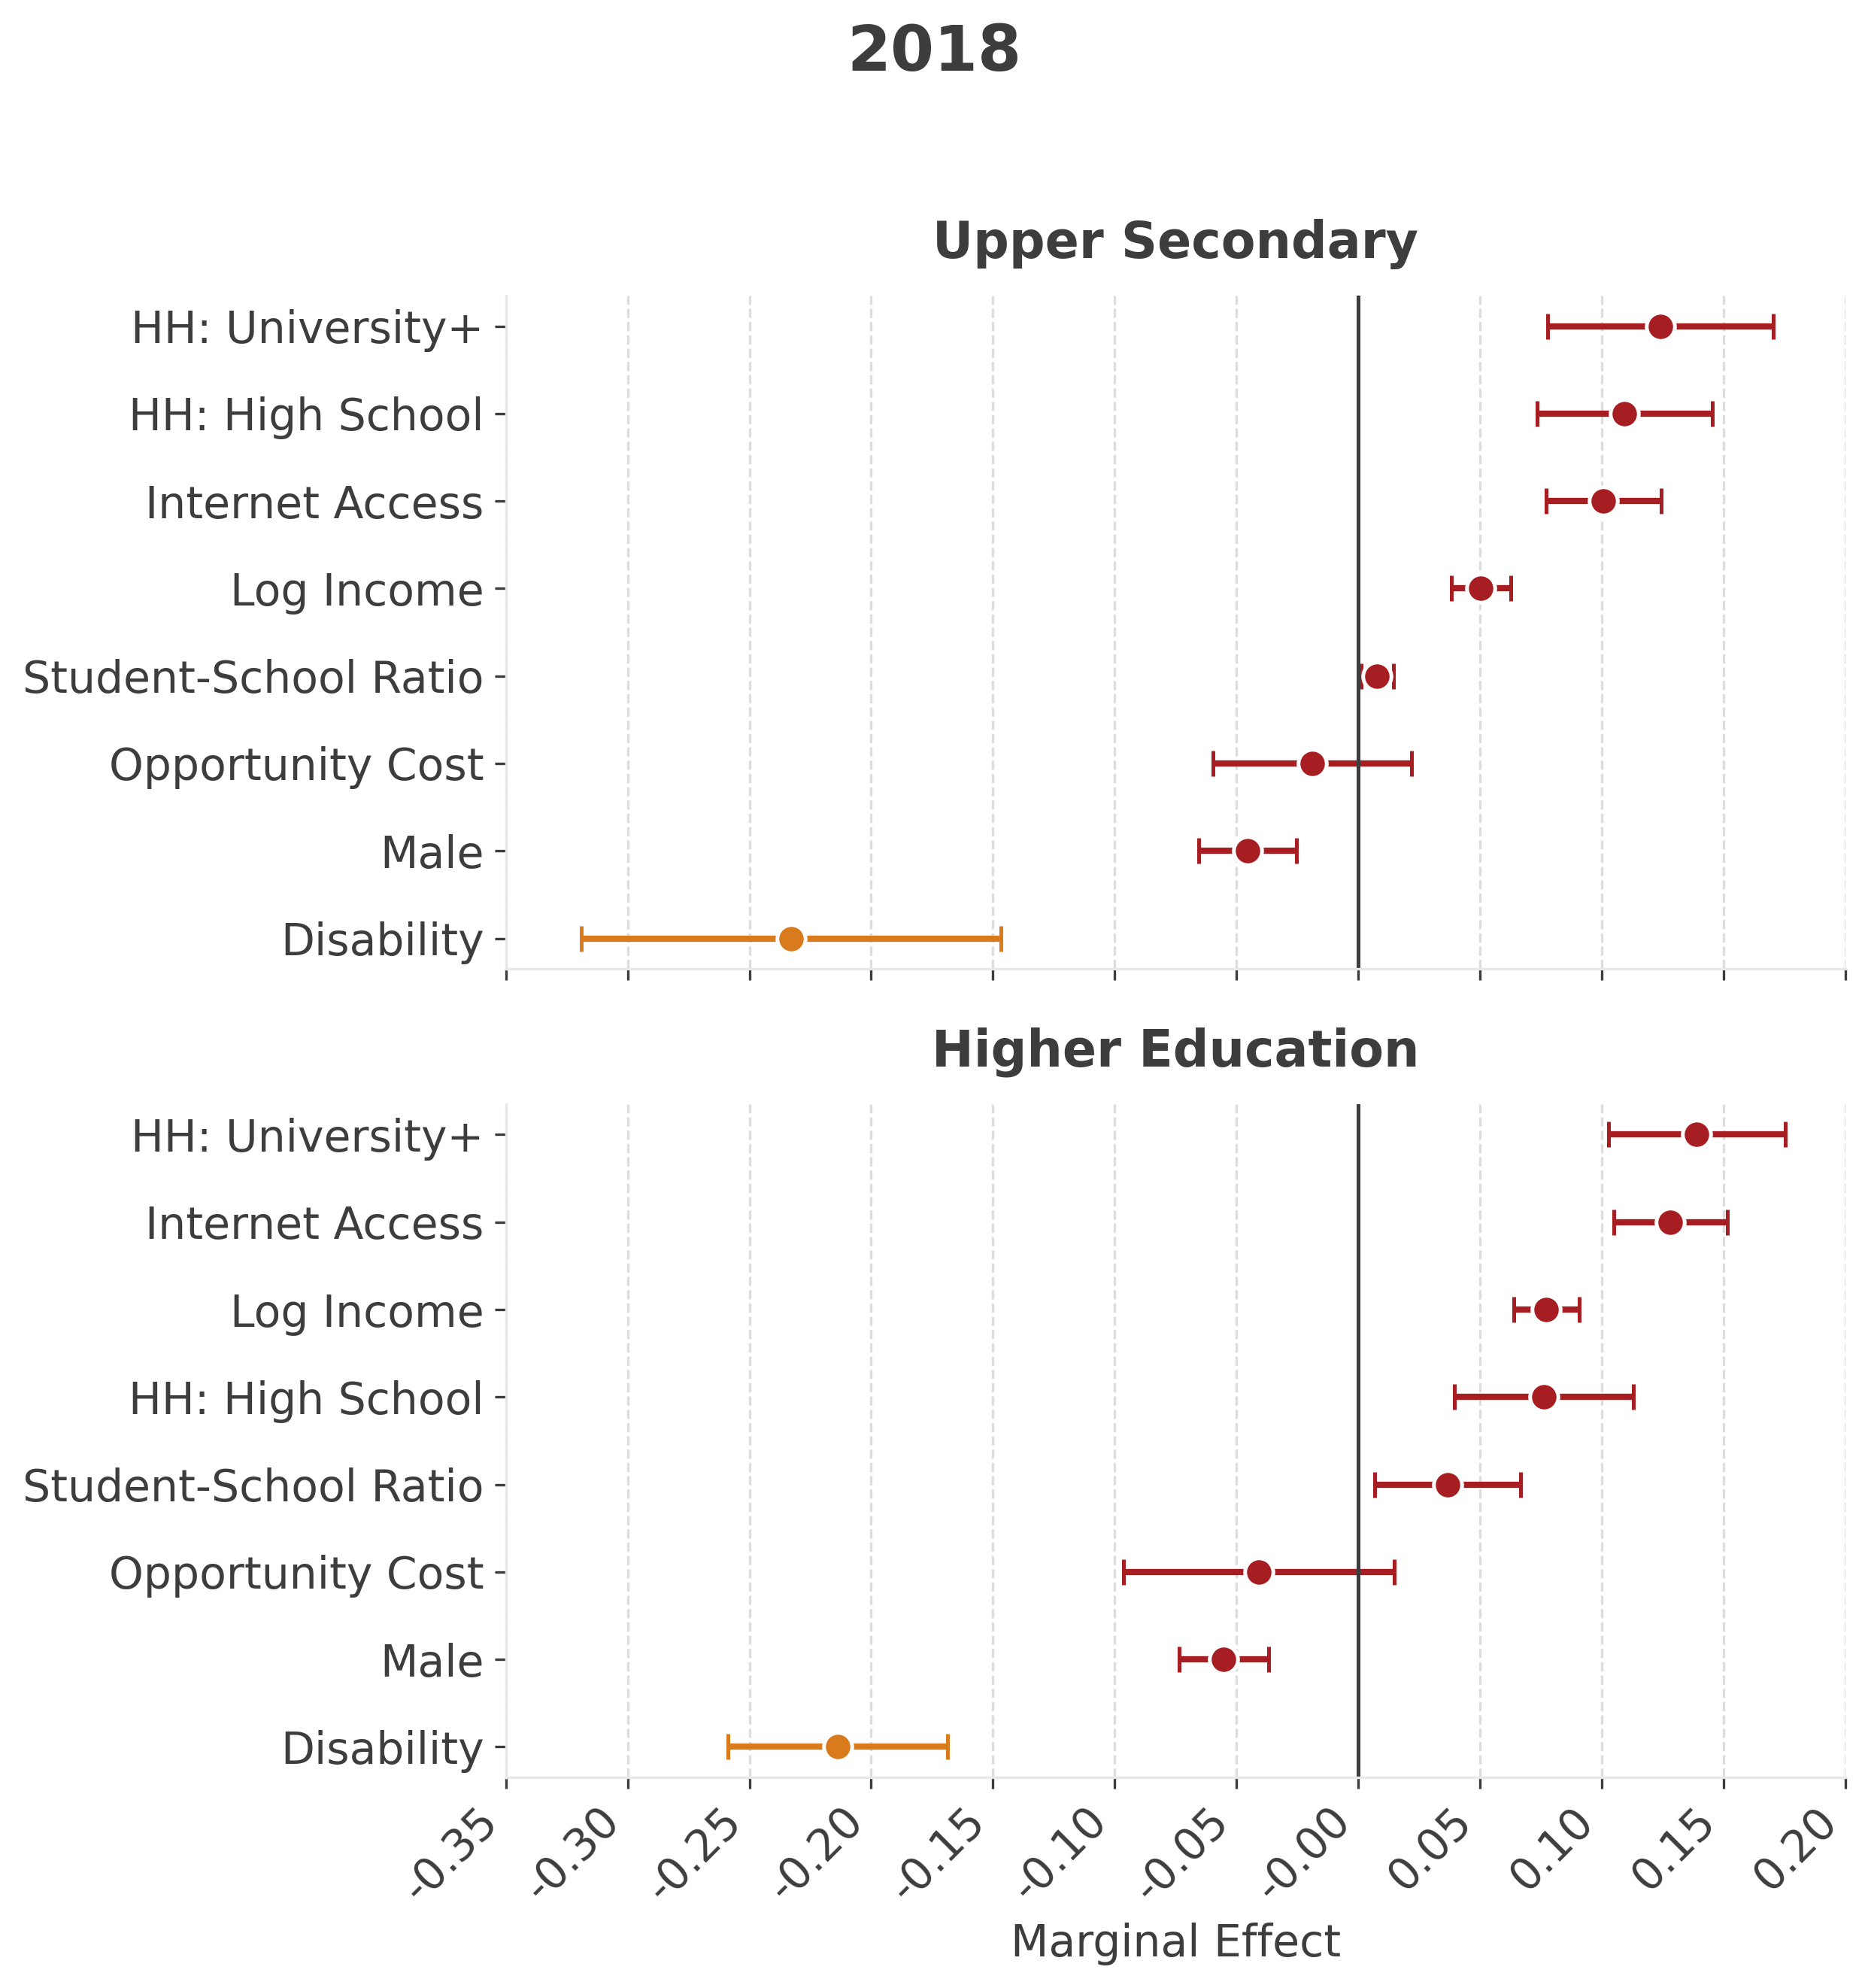

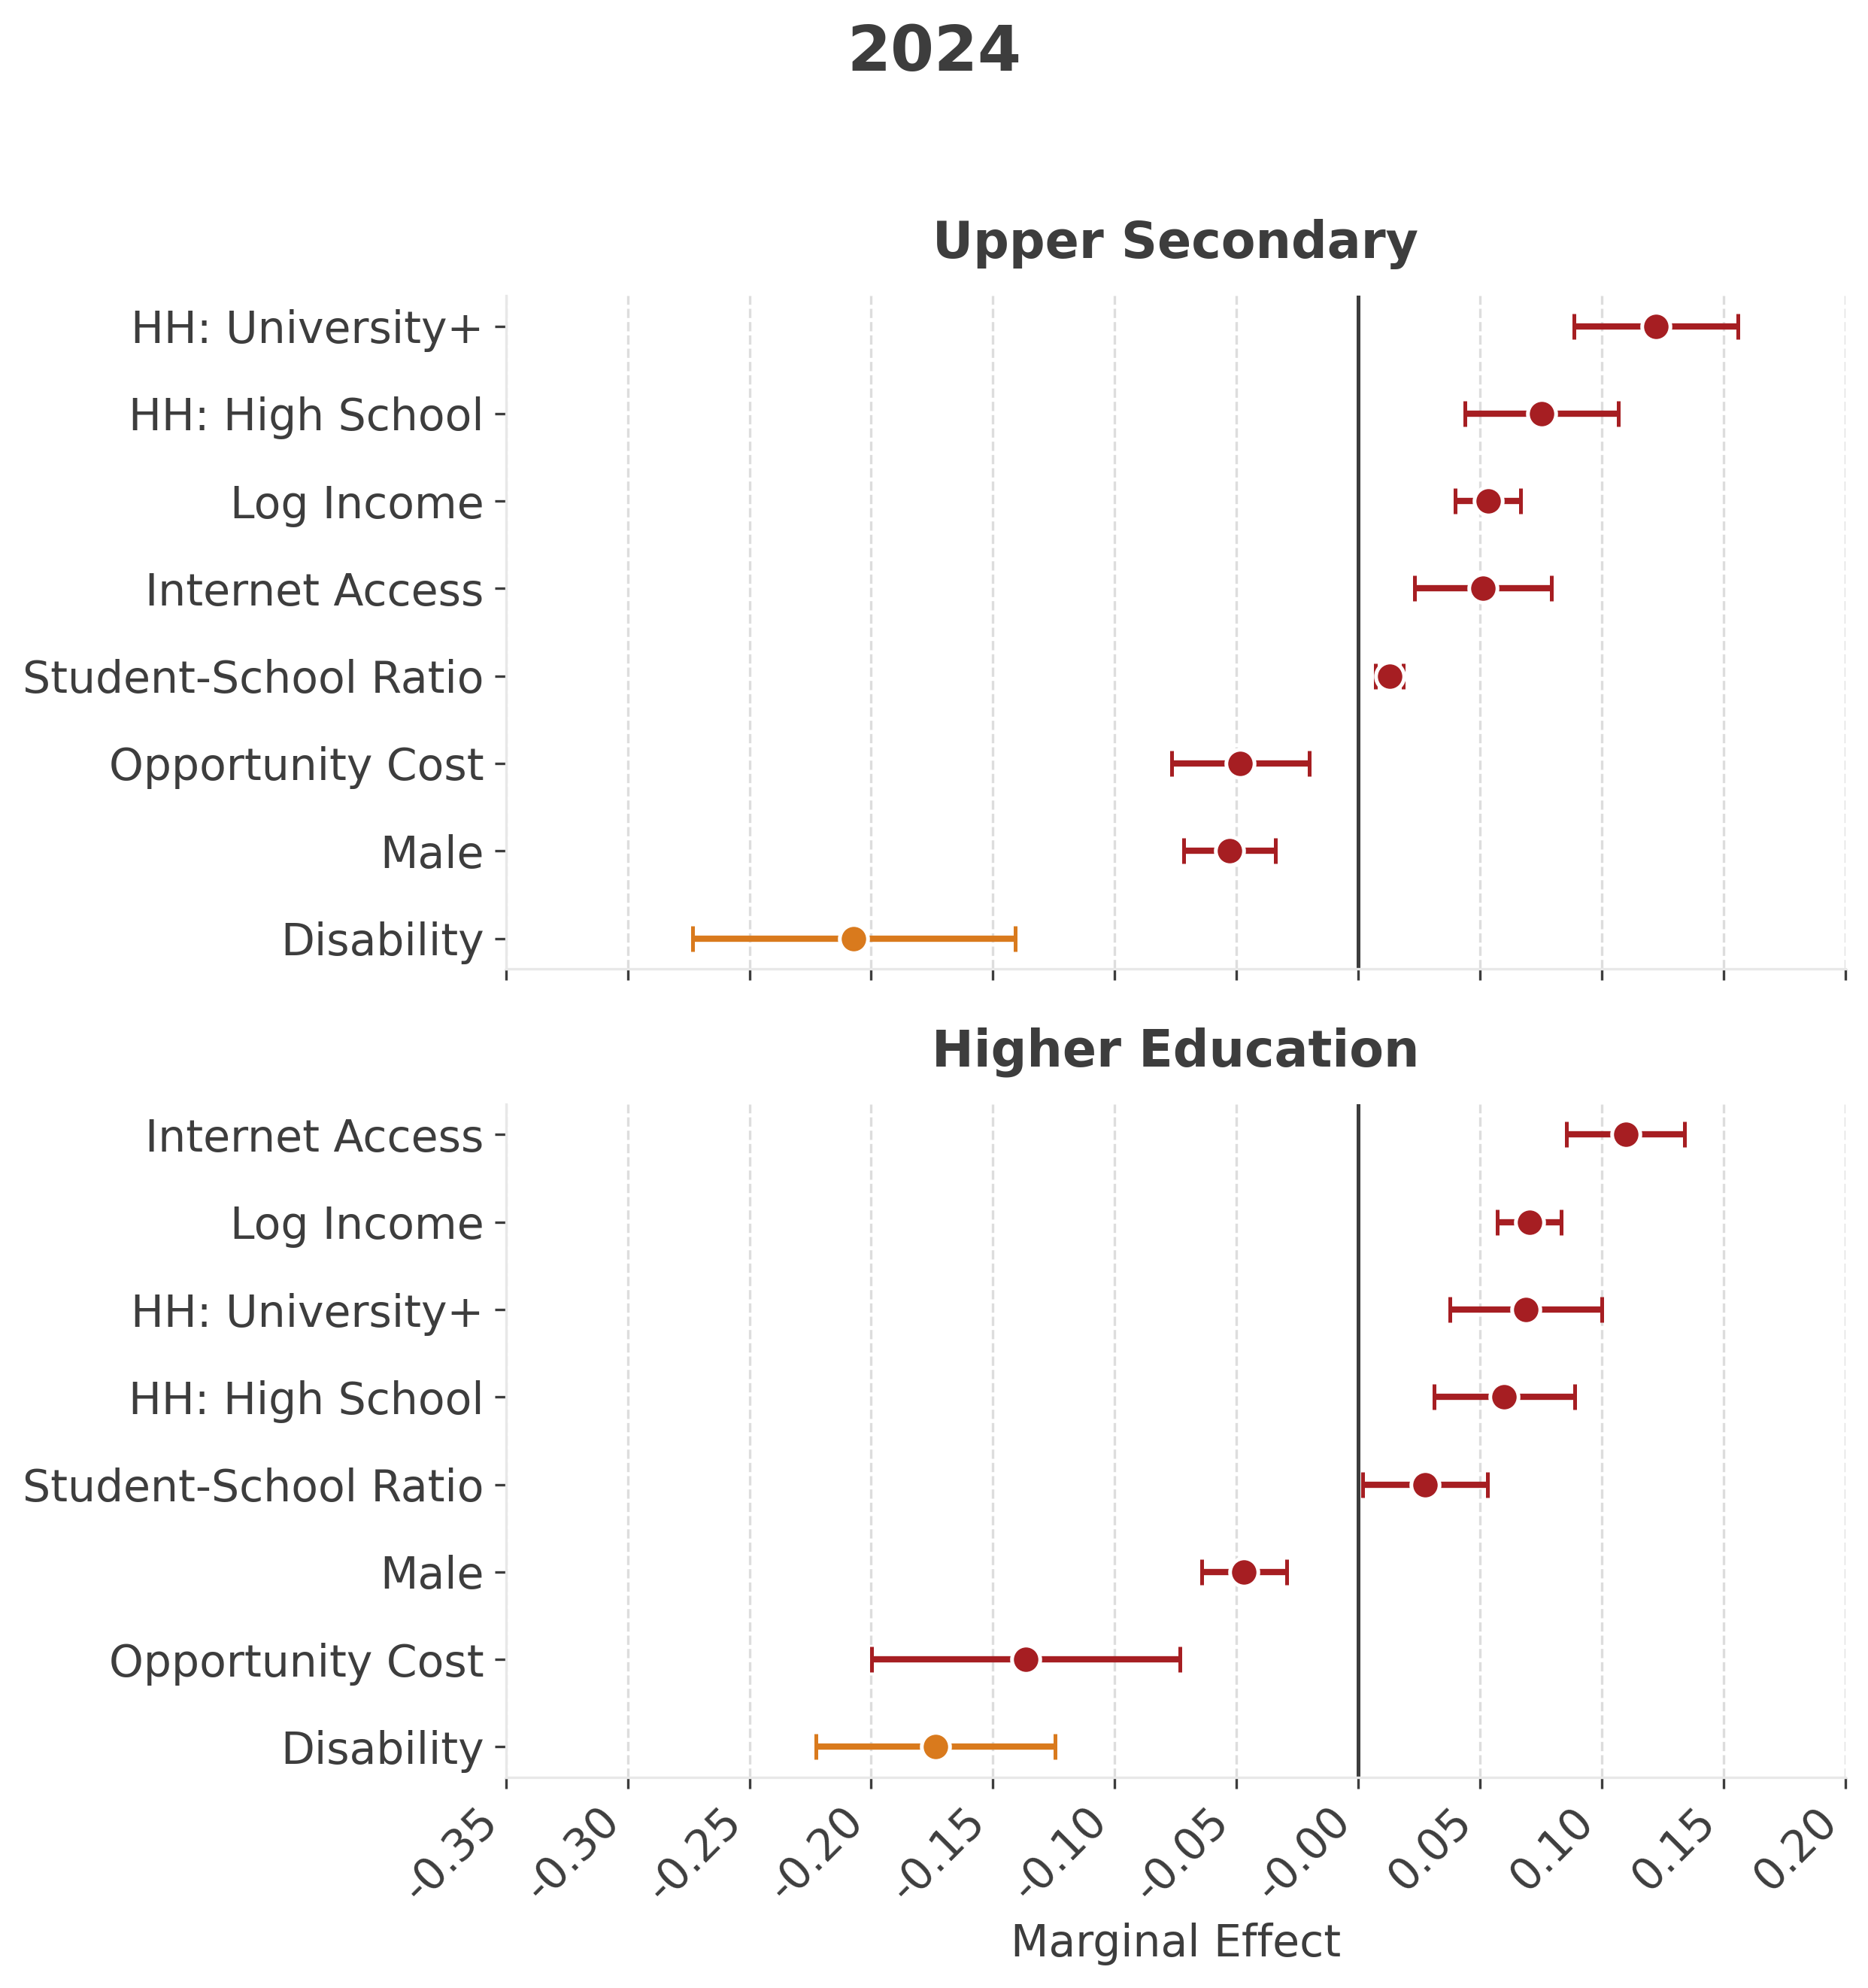

In [34]:
# =====================================================
# FOREST PLOTS COMPACTOS
# FIGURA 1 = 2018
# FIGURA 2 = 2024
# EJE X COMPARTIDO
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# =====================================================
# IDENTIDAD VISUAL
# =====================================================

PRIMARY = "#A61E22"
ACCENT = "#D97A1D"

DARK = "#3D3D3D"
MID = "#7A7A7A"
LIGHT = "#E8E8E8"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14
})

# =====================================================
# FUNCTION
# =====================================================

def compute_ci(effect, t):
    se = abs(effect / t)
    return 1.96 * se

# =====================================================
# VARIABLES A MOSTRAR
# =====================================================

selected_variables = [
    'HH: University+',
    'HH: High School',
    'Internet Access',
    'Male',
    'Disability',
    'Log Income',
    'Opportunity Cost',
    'Student-School Ratio'
]

# =====================================================
# ESCALA COMÚN
# =====================================================

x_min = -0.35
x_max = 0.20

x_ticks = np.arange(
    -0.35,
    0.21,
    0.05
)

# =====================================================
# CONFIGURACIÓN DE FIGURAS
# =====================================================

figures = [
    {
        "year": "2018",
        "models": [
            "Upper Secondary 2018",
            "Higher Education 2018"
        ]
    },
    {
        "year": "2024",
        "models": [
            "Upper Secondary 2024",
            "Higher Education 2024"
        ]
    }
]

# =====================================================
# GENERAR FIGURAS
# =====================================================

for fig_idx, config in enumerate(figures, start=1):

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8.5, 9),
        sharex=True,
        facecolor="white"
    )

    for ax, mod in zip(axes, config["models"]):

        df_mod = df[
            (df["Model"] == mod) &
            (df["Variable"].isin(selected_variables))
        ].copy()

        df_mod = df_mod.sort_values(
            "Effect",
            ascending=True
        )

        labels = [
            textwrap.fill(v, width=22)
            for v in df_mod["Variable"]
        ]

        y_pos = np.arange(len(labels))

        tvals = [
            t_stats[mod][variables.index(v)]
            for v in df_mod["Variable"]
        ]

        ci_vals = [
            compute_ci(eff, t)
            for eff, t in zip(
                df_mod["Effect"],
                tvals
            )
        ]

        # ==========================================
        # VARIABLE MÁS IMPORTANTE
        # ==========================================

        highlight_idx = np.argmax(
            np.abs(df_mod["Effect"])
        )

        colors = [PRIMARY] * len(df_mod)
        colors[highlight_idx] = ACCENT

        # ==========================================
        # FOREST PLOT
        # ==========================================

        for i in range(len(df_mod)):

            ax.errorbar(
                df_mod["Effect"].iloc[i],
                y_pos[i],
                xerr=ci_vals[i],
                fmt='o',
                color=colors[i],
                markerfacecolor=colors[i],
                markeredgecolor='white',
                markeredgewidth=1.2,
                markersize=9,
                capsize=4,
                elinewidth=2
            )

        # ==========================================
        # LÍNEA DE REFERENCIA
        # ==========================================

        ax.axvline(
            0,
            color=DARK,
            linewidth=1.2
        )

        # ==========================================
        # FORMATO
        # ==========================================

        subtitle = (
            "Upper Secondary"
            if "Upper" in mod
            else "Higher Education"
        )

        ax.set_title(
            subtitle,
            fontsize=16,
            fontweight="bold",
            color=DARK,
            pad=12
        )

        ax.set_yticks(
            y_pos
        )

        ax.set_yticklabels(
            labels
        )

        ax.grid(
            axis='x',
            linestyle='--',
            alpha=0.25,
            color=MID
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.spines['left'].set_color(LIGHT)
        ax.spines['bottom'].set_color(LIGHT)

        ax.tick_params(
            colors=DARK
        )

    # ==============================================
    # EJE X COMPARTIDO
    # ==============================================

    axes[0].tick_params(
        labelbottom=False
    )

    axes[1].set_xlim(
        x_min,
        x_max
    )

    axes[1].set_xticks(
        x_ticks
    )

    axes[1].set_xticklabels(
        [f"{x:.2f}" for x in x_ticks],
        rotation=45,
        ha="right"
    )

    axes[1].set_xlabel(
        "Marginal Effect",
        fontsize=14,
        color=DARK
    )

    # ==============================================
    # TÍTULO GENERAL
    # ==============================================

    fig.suptitle(
        config["year"],
        fontsize=20,
        fontweight="bold",
        color=DARK,
        y=0.98
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )

    # ==============================================
    # EXPORTAR
    # ==============================================

    plt.savefig(
        f"grafica ({fig_idx}).svg",
        format="svg",
        bbox_inches="tight",
        dpi=300
    )

    plt.show()